# Data Exploration: Phase 1 
The most important part for this project is to understand the data we are looking at!
Context: We are given a dataset of user-item interactions from software product reviews. We also have a test set with 5 candidate items for each user, we need to rank the items relevance to each user. 

In [151]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns 

In [2]:
user = pd.read_csv('data/train.csv')
item = pd.read_csv('data/item_metadata.csv')
test = pd.read_csv('data/test.csv')

Lets start wuth the examination of the datatypes of the data, the missing values, the schema and check overlap amongst datasets!

In [4]:
print(user.shape, item.shape, test.shape)

(32206, 5) (8681, 9) (10000, 2)


In [ ]:
user.isna().sum() # amazing no nas!

user_id        0
item_id        0
rating         0
review_text    0
timestamp      0
dtype: int64

In [12]:
item.isna().sum()

item_id              0
title                0
description         42
features            37
categories        8240
main_category        6
store                0
price              592
average_rating       0
dtype: int64

^ Key observations from code cells above I don't wnat to utilize the categories fetaure as it has far to many missing values (8240/8681 missing!).

Next I want to dive into, if the unique user IDs if all are present across the given user dataset and the test dataset. How many times do they show up and such!

In [32]:
user.groupby('user_id').agg(count=('user_id', 'count')).reset_index()  # how many times does each user show up, in user dataset?

,user_id,count
0,u_0000,10
1,u_0001,13
2,u_0002,10
3,u_0003,12
4,u_0004,30
...,...,...
1995,u_1995,42
1996,u_1996,11
1997,u_1997,12
1998,u_1998,10


In [31]:
test.groupby('user_id').agg(count=('user_id', 'count')).reset_index()

,user_id,count
0,u_0000,5
1,u_0001,5
2,u_0002,5
3,u_0003,5
4,u_0004,5
...,...,...
1995,u_1995,5
1996,u_1996,5
1997,u_1997,5
1998,u_1998,5


Another point of inquiry would be are there items in the test.csv (products we want to rank for reccomendation to the user) products/items that we don't user-interaction history for in our user-item interaction data (train.csv).

In [34]:
# Lets start by getting a data frame of each unique Item ID from the user-iteminteraction data and the test data 
test_unique_item_count = test.groupby('item_id').agg(count=('item_id', 'count')).reset_index()

In [35]:
test_unique_item_count

,item_id,count
0,i_0000,1
1,i_0003,1
2,i_0005,2
3,i_0007,3
4,i_0008,1
...,...,...
5329,i_8676,3
5330,i_8677,3
5331,i_8678,2
5332,i_8679,2


In [36]:
user_unique_item_count = user.groupby('item_id').agg(count=('item_id', 'count')).reset_index()

In [37]:
user_unique_item_count

,item_id,count
0,i_0000,1
1,i_0001,1
2,i_0002,1
3,i_0003,1
4,i_0004,1
...,...,...
8132,i_8669,1
8133,i_8670,1
8134,i_8671,1
8135,i_8677,1


In [46]:
diff_items = test_unique_item_count.merge(
    user_unique_item_count[['item_id']], 
    on='item_id', 
    how='left', 
    indicator=True
).query('_merge == "left_only"').drop(columns='_merge')


In [47]:
diff_items

,item_id,count
3,i_0007,3
5,i_0011,2
29,i_0065,1
38,i_0082,2
51,i_0108,1
...,...,...
5327,i_8674,1
5328,i_8675,1
5329,i_8676,3
5331,i_8678,2


In [ ]:
len(set(item.item_id) & set(diff_items.item_id)) # these missing user-item interaction items still exist in our item metadata 

544

Note: These items that exist in our item_metadata.csv, we will be building item vectors from metadata not the interaction history which will mean we can inherently handle these items that don't have any recorded user interaction history.

### Distribution Analysis

We will be looking at a numerical feature that is apprent in both the interaction dataset and the item dataset which is ratings.

Text(0.5, 1.0, 'User-item Interaction Data Rating Distribution')

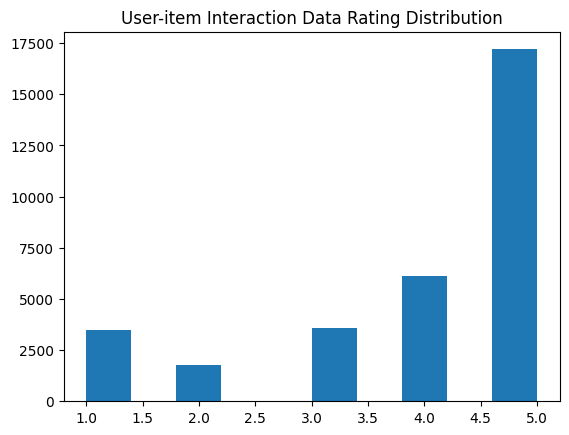

In [65]:
plt.hist(user['rating'])
plt.title('User-item Interaction Data Rating Distribution')

Text(0.5, 1.0, ' Item Average Rating Distribution')

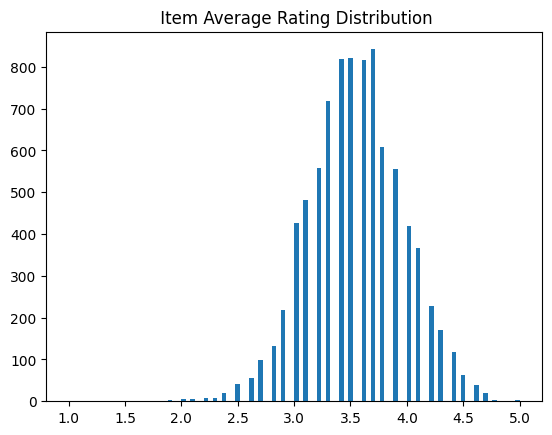

In [67]:
plt.hist(item['average_rating'], bins = 100)
plt.title(' Item Average Rating Distribution')

Note: We see that the user-item interactation dataset having mostly 4 or 5 star reviews where as the item metadata dataset has an approximately normal distribution centered around approximaely 3.5. \ 
What does this mean for us? We have to think about weighting of vectors and think about how or if we should use ratings as weights. 

I think I want to go for a TF-IDF approach where on the item side I will be taking the items metadata convert to TF-IDF vector (which we can imagine as a vector in word importance space) and on user side we will look at the items each user has interacted with create an average of their TF-IDF vectors to get each user's profile vector. And then find the TF-IDF item vectors that are most similar to teh user's profile vectors. 

In the context of this project we have user-item interactions which show us ratings of each of the products users like and what each user likes. But one of our few indicators of this is captured through rating where teh ratings are mostly 4 or 5. The item metadata dataset's average ratings for each product however are approximately normally distributed.

I want to think about TF-IDF weights and how based on the skewed ratings how I should think about how much a user's rating should scale am item's vector, or if I should even do this. 

Lets start to plan out things 
Input: For each user, 5 specific candidate items (from test.csv)
Output: Rank those 5 items by relevance to that user

I think I want to find the cosine similarity for each user-candidate pair. 
The candidate TF-IDF vector will come from the item metadata. And we can get a user profile vector of the weighted average of item vectors from the user's rated items in train.csv. Based on the cosine similarity score we can rank from teh highest to lowest score. 

When building the user profile lets create a centering rating-weighted average of item vectors approach when dealing with ratings to overcome the skew.

| Raw rating | User mean (example) | Centered weight | Interpretation |
|------------|---------------------|----------------|----------------|
| 5          | 4.5                 | +0.5           | Slightly better than usual |
| 4          | 4.5                 | -0.5           | Slightly worse than usual |


In [131]:
item.groupby('main_category').agg(count=('main_category', 'count')).reset_index()

,main_category,count
0,Appstore for Android,8223
1,Computers,1
2,Software,451


### Deep Dive On The Text 

In [74]:
# We have previously shown how many reviews each unique user has, in our user-item interaction dataset
user.groupby('user_id').agg(count=('user_id', 'count')).reset_index() 

,user_id,count
0,u_0000,10
1,u_0001,13
2,u_0002,10
3,u_0003,12
4,u_0004,30
...,...,...
1995,u_1995,42
1996,u_1996,11
1997,u_1997,12
1998,u_1998,10


Text(0.5, 0, '# of Reviews')

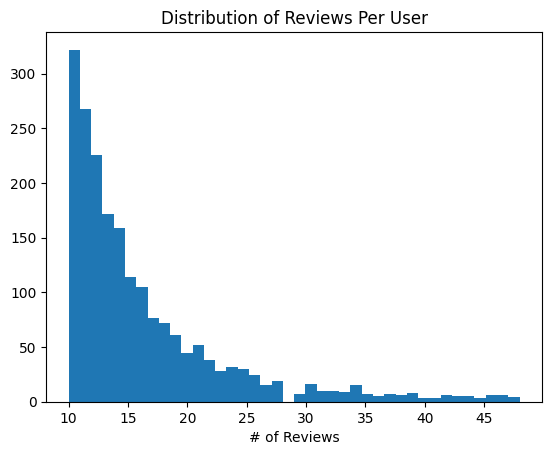

In [77]:
plt.hist(user.groupby('user_id').agg(count=('user_id', 'count')), bins=40)
plt.title('Distribution of Reviews Per User')
plt.xlabel('# of Reviews')

In [83]:
user_stats = user.groupby('user_id').agg(
    review_count=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    std_rating=('rating', 'std'),
    min_timestamp=('timestamp', 'min'),
    max_timestamp=('timestamp', 'max')
).reset_index()

user_stats['timestamp_span_years'] = (user_stats['max_timestamp'] - user_stats['min_timestamp']) / (1000*3600*24*365)


In [84]:
user_stats

,user_id,review_count,avg_rating,std_rating,min_timestamp,max_timestamp,timestamp_span_years
0,u_0000,10,4.800000,0.632456,1511544882103,1634331998888,3.893554
1,u_0001,13,4.538462,0.518875,1300983787000,1420728531000,3.797081
2,u_0002,10,4.600000,0.699206,1389758484000,1437452830000,1.512378
3,u_0003,12,3.583333,1.505042,1395259482000,1473875995000,2.492913
4,u_0004,30,5.000000,0.000000,1451493386000,1451499745000,0.000202
...,...,...,...,...,...,...,...
1995,u_1995,42,4.476190,0.633923,1374684827000,1602861001114,7.235419
1996,u_1996,11,3.272727,1.618080,1142010400000,1589744465431,14.197554
1997,u_1997,12,4.083333,0.288675,1412883177000,1412885629000,0.000078
1998,u_1998,10,4.900000,0.316228,1548455061189,1564063613038,0.494944


In [86]:
user_stats[['avg_rating','std_rating','timestamp_span_years']].describe()

,avg_rating,std_rating,timestamp_span_years
count,2000.000000,2000.000000,2000.000000
mean,3.986096,0.994475,2.952750
std,0.814887,0.536741,2.478795
min,1.000000,0.000000,0.000003
25%,3.500000,0.574924,0.943795
50%,4.108187,1.055407,2.464898
75%,4.636364,1.414214,4.424534
max,5.000000,2.088932,17.244775


In [ ]:
# Lets start with checking availability of each of the features in the data
print("Description present:", item.description.notna().sum(), "/", len(item))
print("Features present:", item.features.notna().sum(), "/", len(item))
print("Main Categories present: ", item.main_category.notna().sum(), "/", len(item)) # not using categories bc too sparse
# (already did above in basic eda just to show...)

Description present: 8639 / 8681
Features present: 8644 / 8681
Categories present:  8675 / 8681


In [94]:
# Lets check the length of each written feature, before that we want to fill each na with an empty string
item['title_len']   = item.title.fillna('').str.len()
item['desc_len']    = item.description.fillna('').str.len()
item['feat_len']    = item.features.fillna('').str.len()

In [95]:
item

,item_id,title,description,features,categories,main_category,store,price,average_rating,title_len,desc_len,feat_len
0,i_5165,Mahjong 2015,Mahjong 2015 is a free solitaire matching game...,Mahjong 2015 is a free solitaire matching game...,NaN,Appstore for Android,sophiathach,0.00,3.1,12,643,647
1,i_7178,RoverCraft Race Your Space Car,Play The World Famous Car Crafting Runner with...,14 different planets from the galaxy to race o...,NaN,Appstore for Android,Mobirate,0.00,3.9,30,1912,609
2,i_4289,Just Escape,"Just Escape, whether it's a medieval castle or...",Escape from rooms deep in a medieval castle or...,NaN,Appstore for Android,Inertia Game Studios,0.00,3.5,11,153,216
3,i_4772,TurboTax Deluxe 2014 Fed + State + Fed Efile T...,Tax Software that helps you get your taxes don...,This product is backed by Intuit’s 60 Day Mone...,"Software, Intuit, All Intuit",Software,Intuit,NaN,4.4,86,811,727
4,i_4232,How to Draw: Frozen,Frozen Characters drawing lessons are grouped ...,Free to use! Portable so you can learn to draw...,NaN,Appstore for Android,DrawMate,0.00,3.7,19,140,369
...,...,...,...,...,...,...,...,...,...,...,...,...
8676,i_2903,Office Suite,Office Suite is the best alternative to other ...,Includes a complete word processor to help wit...,"Software, Children's",Software,Encore,NaN,2.7,12,257,394
8677,i_0638,Corel Photo and Video Pro X4 Ultimate Bundle [...,Product Description With our best photo- and v...,Ultimate bundle combines powerful photo- and v...,"Software, Corel, All Corel",NaN,Corel,99.99,3.1,58,5740,365
8678,i_3518,Corel WinZip 18 [Old Version],Unzip all major formats Protect your privacy V...,The world's #1 compression software Privacy pr...,"Software, Corel, All Corel",Software,Corel,NaN,3.2,29,1743,613
8679,i_3096,Quicken Rental Property Manager 2014 [OLD VERS...,From the Manufacturer Intuit Quicken Rental Pr...,Organizes your personal and rental property fi...,"Software, Accounting & Finance, Personal Finan...",Software,Intuit,NaN,3.1,50,11522,251


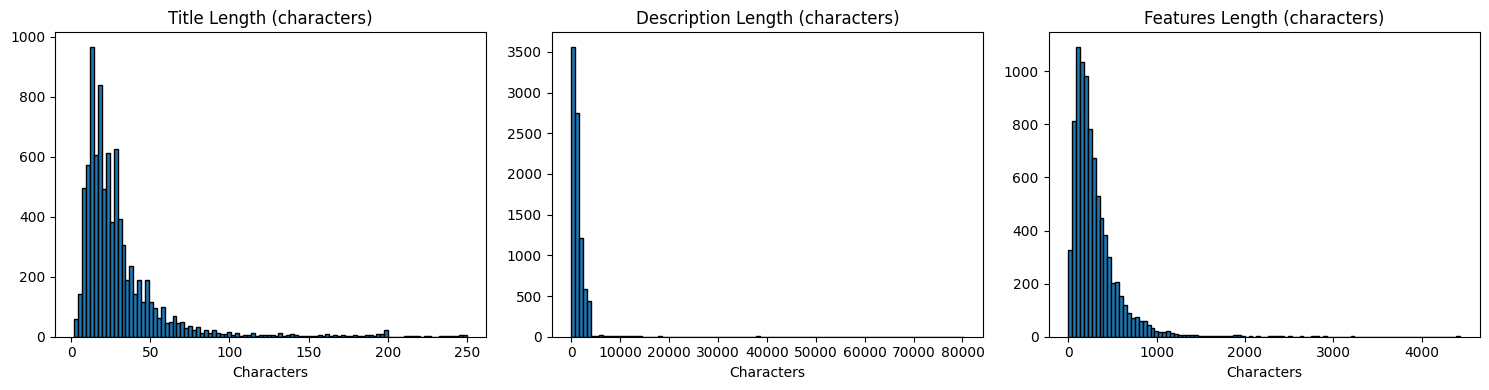

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes, ['title_len','desc_len','feat_len'], ['Title','Description','Features']):
    ax.hist(item[col], bins=100, edgecolor='black')
    ax.set_title(f'{label} Length (characters)')
    ax.set_xlabel('Characters')
plt.tight_layout()

^ This tells us that most of our item text data that describes the item is short

In [ ]:
# I want to check on a random sample and see if the description and features sometimes overlap, seems that the only time it kind of did out of 7 is on the calculator app
both = item[item.description.notna() & item.features.notna()].sample(7, random_state=42)
for _, row in both.iterrows():
    print("TITLE:",row['title'])
    print("DESC:",row['description'][:300])
    print("FEAT:",row['features'][:300])
    print("- - - -")

TITLE: Graphing Calculator
DESC: The Simple Graphing CalculatorA Simple Graphing Calculator- Added Basic Calculator- Added Scientific Calculator- Added Graphing Calculator- Pinch Zoom for Graphing Calculator- Take Screenshot of Graph- Added Tablet Screen Size Support- Improved User Interaction for Graphing Calculator- Scientific No
FEAT: - Added Basic Calculator - Added Scientific Calculator - Added Graphing Calculator - Pinch Zoom for Graphing Calculator - Take Screenshot of Graph - Added Tablet Screen Size Support - Improved User Interaction for Graphing Calculator - Scientific Notation - Radian vs Degree - copy and paste using cl
- - - -
TITLE: CHARIOT WARS
DESC: Chariot Wars is a AAA quality story-driven racing game set in Ancient Rome. Featuring stunning visuals, the game features both singleplayer and multiplayer modes.Game Features• Singleplayer arcade racing including Championship and Time Trial modes• 4 player multiplayer• Game levels set in Ancient Gr
FEAT: Singleplayer arcad

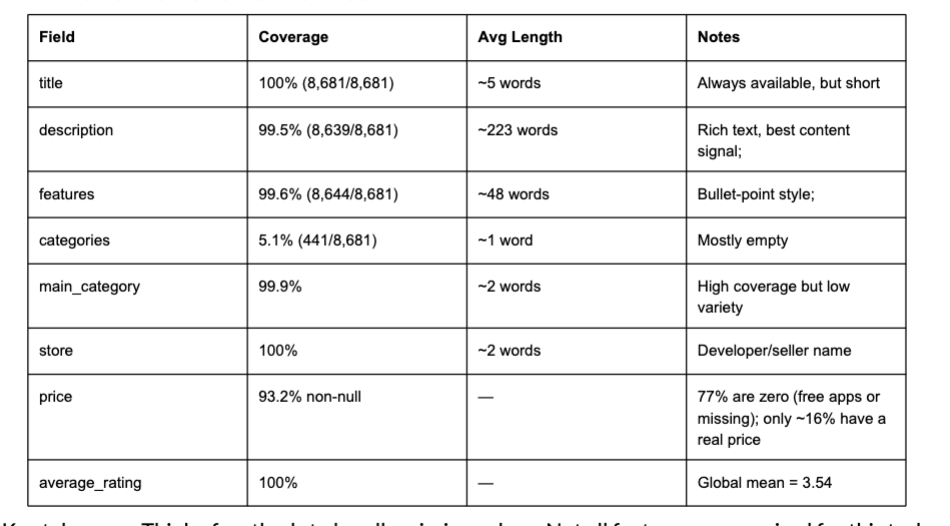

In [104]:
# Lets Now check out more information on the review text data 

user['review_len'] = user.review_text.str.len()


In [105]:
user

,user_id,item_id,rating,review_text,timestamp,review_len
0,u_0000,i_6473,5.0,"I love it ,its so fun and I love that there is...",1511544882103,61
1,u_0000,i_4810,5.0,It's a good game it can get challenging but it...,1528752146440,61
2,u_0000,i_7926,5.0,If you can't get Fortnite then this is probabl...,1548347431071,118
3,u_0000,i_6452,5.0,Awesome game it need to give more money for ev...,1559959233554,67
4,u_0000,i_8085,5.0,It's very fun and good game,1567350456713,27
...,...,...,...,...,...,...
32201,u_1999,i_3813,5.0,Really makes you think. And glad there are hi...,1399050750000,119
32202,u_1999,i_3380,5.0,"Love mahjong solitaire, love that it has a lot...",1419604869000,146
32203,u_1999,i_4421,5.0,"Love this game, but it does freeze once in a w...",1429152043000,120
32204,u_1999,i_5835,5.0,"Love it, easy, but makes you use your brain.",1440910123000,44


In [108]:
pd.DataFrame(user.review_len.describe())

,review_len
count,32206.000000
mean,147.582562
std,296.079295
min,11.000000
25%,34.000000
50%,88.000000
75%,162.000000
max,12635.000000


(array([2.2155e+04, 6.2190e+03, 1.8680e+03, 7.3100e+02, 3.6900e+02,
        2.2600e+02, 1.5700e+02, 9.5000e+01, 7.6000e+01, 6.7000e+01,
        2.9000e+01, 2.5000e+01, 2.3000e+01, 2.1000e+01, 1.3000e+01,
        1.3000e+01, 1.4000e+01, 8.0000e+00, 4.0000e+00, 1.0000e+01,
        8.0000e+00, 1.0000e+01, 3.0000e+00, 6.0000e+00, 6.0000e+00,
        2.0000e+00, 5.0000e+00, 6.0000e+00, 5.0000e+00, 2.0000e+00,
        2.0000e+00, 2.0000e+00, 2.0000e+00, 1.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 2.0000e+00, 2.0000e+00, 2.0000e+00,
        2.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 2.0000e+00, 1.0000e+00, 2.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.00

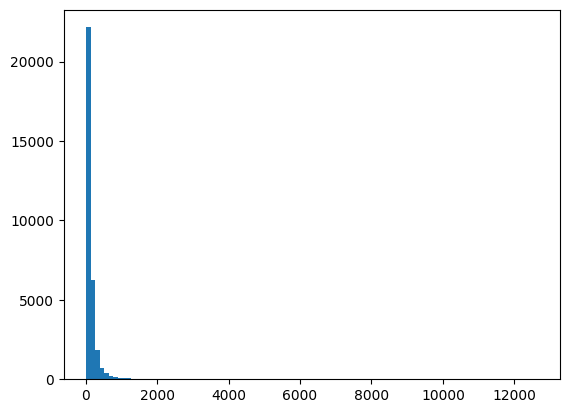

In [ ]:
plt.hist(user.review_len, bins = 100) 
# most of the characer length seemed to be from 0 to 2000 with the max being 12635.000000

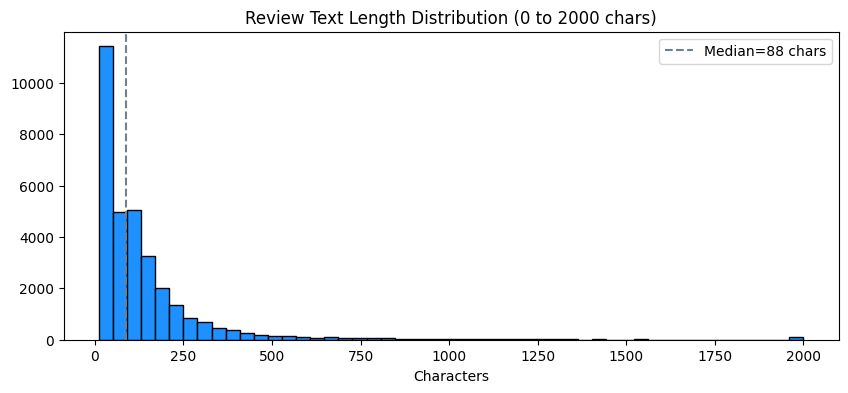

In [119]:
plt.figure(figsize=(10, 4))
plt.hist(user.review_len.clip(0, 2000), bins=50, edgecolor='black', color='dodgerblue')
plt.axvline(user.review_len.median(), color='slategray', linestyle='--', 
            label=f'Median={user.review_len.median():.0f} chars')
plt.title('Review Text Length Distribution (0 to 2000 chars)')
plt.xlabel('Characters')
plt.legend()

In [122]:
# Lets see an example of really short reviews
pd.DataFrame(user[user.review_len < 30].review_text.sample(15))

,review_text
7514,Loads of fun
6382,OMG!!!! BEST GAME EVA!!!! 😍😍😍
10067,Works well.
28481,I did not like.
15955,Works Great!
17206,Great product!
25838,Works Perfectly
24746,Google is great
8063,Didn't work on my phone.
18220,This is a fun game.


In [127]:
cold_items = set(test.item_id) - set(user.item_id)


### Quick Cold Item Dive

In [ ]:
cold_items = set(test.item_id) - set(user.item_id)
# a set will give us all unique values of id for each set the difference will tell us the items that appear in the test dataset that don't appear in the user-item interaction dataset

In [ ]:
cold_item_set = item[item.item_id.isin(cold_items)] # this will give us item descriptions in the metadata dataset of the cold items that appear in the test set and we don;t have interaction data for

In [133]:
cold_item_set

,item_id,title,description,features,categories,main_category,store,price,average_rating,title_len,desc_len,feat_len
40,i_5529,Fortune Wheel 2 Slots,Fortune Wheel Slots 2 is a highly entertaining...,"- Jackpots starting at 100,000 credits - Up to...",NaN,Appstore for Android,Leetcom,0.00,3.5,21,897,117
42,i_0369,ZDbox ( Root Task Killer ),ZDbox is an amazing all-in-one toolbox. It is ...,Use this all-in-one Android toolbox to make th...,NaN,Appstore for Android,zdworks.com,0.00,2.8,26,715,376
49,i_8660,"TurboTax Deluxe 2022 Tax Software, Federal and...",Get your taxes done right with TurboTax® 2022 ...,"Recommended if you own a home, have charitable...","Software, Intuit, All Intuit",Software,Intuit,NaN,4.5,97,1244,517
50,i_5514,100's of Buttons and Sounds HD,100’s of Buttons and Sounds has an extensive c...,Over 400 buttons (and growing)…that’s right OV...,NaN,Appstore for Android,"Toneaphone, LLC",0.00,3.2,30,1192,212
97,i_1382,EZeye,EZeye allows Android or Kindle users to view a...,NaN,NaN,Appstore for Android,"Longterm Digital Technology Co.,Ltd",0.00,2.7,5,341,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8620,i_5768,Roxio Toast 14 Titanium (Old Version),"Adding easy new DVD video burning software, ne...","Capture, edit and enhance audio with Toast Aud...","Software, Corel, All Corel",Software,Corel,NaN,3.0,37,587,281
8622,i_1901,"iolo - System Mechanic, Fix & Speed Up Your PC...",NaN,"REPAIRS - Finds and fixes over 30,000 differen...","Software, Utilities, PC Maintenance",Software,IOLO Technologies,37.99,3.5,97,0,658
8654,i_0007,Hallmark Scrapbook Studio Deluxe,Amazon.com Scrapbook Studio Deluxe provides an...,NaN,"Software, Lifestyle & Hobbies, Home Publishing...",Software,Vivendi Universal,NaN,3.2,32,665,0
8657,i_8661,"TurboTax Premier 2022 Tax Software, Federal an...",Get your taxes done right with TurboTax® 2022 ...,"Recommended if you sold stock, employee stock,...","Software, Intuit, All Intuit",Software,Intuit,NaN,4.5,117,1303,553


In [ ]:
cold_item_set.isna().sum() # seems to be pretty fill with data 


item_id             0
title               0
description        10
features            5
categories        492
main_category       1
store               0
price              36
average_rating      0
title_len           0
desc_len            0
feat_len            0
dtype: int64

### User Case Study

In [148]:
def inspect_user(user_id, train, meta, test):
    history = train[train.user_id == user_id].sort_values('timestamp')
    candidates = test[test.user_id == user_id]
    
    print(f"=== {user_id} — {len(history)} reviews ===")
    for _, row in history.iterrows():
        m = meta[meta.item_id == row['item_id']].iloc[0]
        print(f"[{row['rating']} stars] {m['title'][:60]}")
        print(f"Review: {str(row['review_text'])[:100]}")
    
    print(f"\nTest candidates:")
    for _, row in candidates.iterrows():
        m = meta[meta.item_id == row['item_id']]
        title = m['title'].values[0] if len(m) else "NOT IN META"
        print(f"{row['item_id']}: {title[:60]}")


In [149]:
inspect_user('u_0000', user, item, test)


=== u_0000 — 10 reviews ===
[5.0 stars] Gods of Olympus
Review: I love it ,its so fun and I love that there is no build times
[5.0 stars] Alien Creeps TD
Review: It's a good game it can get challenging but it's a lot of fun
[5.0 stars] Rocket Royale: PvP Survival
Review: If you can't get Fortnite then this is probably your best bet for a battle royale it's super fun and
[5.0 stars] Tower Crush - Clash of Heroes
Review: Awesome game it need to give more money for every tower you destroy
[5.0 stars] Hovercraft: Getaway
Review: It's very fun and good game
[3.0 stars] Lazy Santa Claus
Review: Because your getting ready to spread cheer but fun
[5.0 stars] Infinity Kingdom
Review: I love this game
[5.0 stars] Slithering Worms
Review: I did not find slither io but when I met this is slither io but way Different
[5.0 stars] Minecraft
Review: New boss will be the boss
[5.0 stars] Hero Tower Wars
Review: If there was multi player it would be fun is just a puzzle but can there be a battle mode.



In [150]:
inspect_user('u_0050', user, item, test)


=== u_0050 — 16 reviews ===
[5.0 stars] Gold Fish Casino Slots – Free Online Slot Machines
Review: Like this game.
[5.0 stars] Homescapes
Review: Very challenging but fun game.
[4.0 stars] Gardenscapes
Review: Tough but fun.
[4.0 stars] Clockmaker: Match 3 Puzzle Games
Review: Not easy, but fun.
[5.0 stars] Double Win Slots - Free Vegas Casino Games
Review: Great past time!
[4.0 stars] Word Fall - Brain training search word puzzle game
Review: Makes you think rather than slot machines.
[4.0 stars] Lotsa Slots - Vegas Casino SLOTS Free with bonus
Review: Pretty fun game. Like the different bonus  games.
[5.0 stars] Lily’s Garden - Match, Design & Decorate
Review: Pretty enjoyable to pass the time.
[5.0 stars] Jewels Temple Quest
Review: It's colorful and challenging, but not impossible to solve.  I don't get bumped out of the game and 
[4.0 stars] Jewelry King
Review: I enjoy these types of games.  They make my brain work.
[4.0 stars] Cube Rush
Review: I am enjoying this game.
[4.0 star